In [1]:
# Bibliotecas padrão do Python
from dataclasses import dataclass
from pathlib import Path
from typing import Sequence, Union

# Bibliotecas para cálculos numéricos
import numpy as np

# Bibliotecas para visualização
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb, rgb_to_hsv

# Bibliotecas para manipulação de imagens
from PIL import Image, ImageDraw

# Bibliotecas para exibição no Jupyter Notebook
from IPython.display import HTML, display

##### QUESTÃO1 

###### 1.

In [2]:
@dataclass
class Circulo:
    centro: tuple[int, int]
    raio: int
    tom: int = 110
    alfa: int = 190


@dataclass
class Reta:
    inicio: tuple[int, int]
    fim: tuple[int, int]
    tom: int = 20
    alfa: int = 255
    largura: int = 3


@dataclass
class Poligono:
    vertices: list[tuple[int, int]]
    tom: int = 80
    alfa: int = 165

###### 2. 

In [3]:
Descritor = Union[Circulo, Reta, Poligono]


def renderizar(descritores: Sequence[Descritor], tamanho=(100, 100)):
    base = Image.new("RGBA", tamanho, (255, 255, 255, 255))
    camadas = []

    for forma in descritores:
        camada = Image.new("RGBA", tamanho, (0, 0, 0, 0))
        pincel = ImageDraw.Draw(camada)
        cor = (forma.tom, forma.tom, forma.tom, forma.alfa)

        if isinstance(forma, Circulo):
            cx, cy = forma.centro
            r = forma.raio
            pincel.ellipse((cx-r, cy-r, cx+r, cy+r), fill=cor)
        elif isinstance(forma, Reta):
            pincel.line((forma.inicio, forma.fim), fill=cor, width=forma.largura)
        elif isinstance(forma, Poligono):
            if len(forma.vertices) < 3:
                raise ValueError("Um polígono precisa de pelo menos 3 vértices.")
            pincel.polygon(forma.vertices, fill=cor)
        else:
            raise TypeError(f"Descritor desconhecido: {type(forma).__name__}")

        camadas.append(camada)
        base = Image.alpha_composite(base, camada)

    return base.convert("L"), base, camadas

###### 3.

In [ ]:
import seaborn as sns

cena = [
    Circulo(centro=(50, 50), raio=30),
    Poligono(vertices=[(20, 20), (80, 20), (50, 70)]),
    Reta(inicio=(10, 90), fim=(90, 90)),
]

# A célula 2 transforma os descritores em camadas e em um bitmap final.
imagem_cinza, imagem_rgba, camadas = renderizar(cena)
imagem_cinza.save("questao1_bitmap_cinza.png")

fig, eixos = plt.subplots(1, len(cena) + 1, figsize=(16, 4))
titulos = [f"Camada {i}: {type(forma).__name__}"
           for i, forma in enumerate(cena, start=1)]
titulos.append("Composição final em cinza")
fundo = Image.new("RGBA", imagem_rgba.size, "white")

for indice, eixo in enumerate(eixos):
    if indice < len(camadas):
        dados = np.asarray(Image.alpha_composite(fundo, camadas[indice]).convert("L"))
    else:
        dados = np.asarray(imagem_cinza)

    sns.heatmap(dados, cmap="gray", vmin=0, vmax=255,
                cbar=False, square=True, xticklabels=20,
                yticklabels=20, ax=eixo)
    eixo.set(title=titulos[indice], xlabel="x (pixels)", ylabel="y (pixels)")

plt.tight_layout()
plt.show()

---
# Questão 2 — Contraste na componente L (HSL)

**Situação-problema:** aplicar contraste a uma fotografia alterando somente a componente de luminosidade **L**, preservando matiz **H** e saturação **S**.

**Itens solicitados:** (1) carregar uma imagem colorida; (2) converter RGB → HSL; (3) normalizar L e aplicar $L'=(L-0{,}5)\times1{,}8+0{,}5$; (4) reconstruir RGB; (5) mostrar imagem original, L antes, L depois e imagem final.

**Desafio extra:** converter para HSV e comparar o efeito de alterar o canal **V**.

**Nota de implementação:** RGB, H, S, L e V são trabalhados como valores reais de 0 a 1. A normalização por mínimo e máximo é aplicada a L; depois o resultado da fórmula é limitado a `[0, 1]` para formar uma imagem válida. As funções abaixo usam a ordem de canais **H, S, L**, embora a biblioteca `colorsys` costume chamar a ordem de HLS.

### 2.1 — Carregamento da imagem
Para trabalhar no Colab, defina `USAR_UPLOAD_COLAB = True`. Em Jupyter local, informe `CAMINHO_IMAGEM`. Sem imagem informada, será criada uma imagem colorida de demonstração, permitindo executar todo o notebook sem arquivos extras.

Usando imagem RGB de demonstração; configure o upload para usar sua foto.


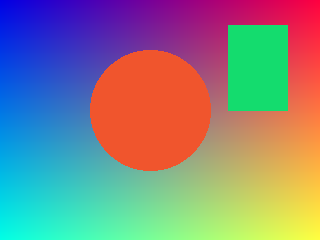

In [5]:
USAR_UPLOAD_COLAB = False  # Altere para True apenas no Google Colab
CAMINHO_IMAGEM = None       # Exemplo em Jupyter: "minha_foto.jpg"


def imagem_de_demonstracao(largura=320, altura=240):
    yy, xx = np.mgrid[0:altura, 0:largura]
    amostra = np.stack([
        np.broadcast_to(xx / (largura - 1), (altura, largura)),
        np.broadcast_to(yy / (altura - 1), (altura, largura)),
        0.25 + 0.65 * (1 - xx / (largura - 1)),
    ], axis=-1)
    resultado = Image.fromarray(np.rint(amostra * 255).astype(np.uint8), "RGB")
    lapis = ImageDraw.Draw(resultado)
    lapis.ellipse((90, 50, 210, 170), fill=(240, 85, 45))
    lapis.rectangle((228, 25, 287, 110), fill=(20, 220, 110))
    return resultado


if USAR_UPLOAD_COLAB:
    try:
        from google.colab import files
    except ImportError as erro:
        raise RuntimeError("A opção de upload requer Google Colab.") from erro
    enviados = files.upload()
    if not enviados:
        raise ValueError("Nenhuma imagem foi enviada.")
    CAMINHO_IMAGEM = next(iter(enviados))

if CAMINHO_IMAGEM is not None:
    caminho = Path(CAMINHO_IMAGEM)
    if not caminho.is_file():
        raise FileNotFoundError(f"Imagem não encontrada: {caminho}")
    imagem_original = Image.open(caminho).convert("RGB")
    # Limita o tamanho para que o processamento e a exibição sejam rápidos.
    imagem_original.thumbnail((750, 750))
    print("Imagem carregada:", caminho)
else:
    imagem_original = imagem_de_demonstracao()
    print("Usando imagem RGB de demonstração; configure o upload para usar sua foto.")

display(imagem_original)

### 2.2 — Conversão vetorizada RGB ↔ HSL
O canal H é obtido pelo canal de maior intensidade, L é a média entre máximo e mínimo, e S depende da amplitude entre eles. A reconstrução usa cromaticidade (`C`), componente intermediária (`X`) e deslocamento (`m`).

In [6]:
def rgb_para_hsl(rgb):
    """RGB float [0,1] -> HSL float [0,1], vetorizado com NumPy."""
    rgb = np.asarray(rgb, dtype=np.float64)
    r, g, b = np.moveaxis(rgb, -1, 0)
    maior = rgb.max(axis=-1)
    menor = rgb.min(axis=-1)
    delta = maior - menor
    l = (maior + menor) / 2.0

    s = np.zeros_like(l)
    denominador = 1.0 - np.abs(2.0*l - 1.0)
    np.divide(delta, denominador, out=s, where=denominador > 1e-12)

    h = np.zeros_like(l)
    mascara = delta > 1e-12
    mr = mascara & (maior == r)
    mg = mascara & ~mr & (maior == g)
    mb = mascara & ~mr & ~mg
    h[mr] = ((g[mr] - b[mr]) / delta[mr]) % 6
    h[mg] = (b[mg] - r[mg]) / delta[mg] + 2
    h[mb] = (r[mb] - g[mb]) / delta[mb] + 4
    h /= 6.0
    return np.stack([h, s, l], axis=-1)


def hsl_para_rgb(hsl):
    """HSL float [0,1] -> RGB float [0,1]."""
    h, s, l = np.moveaxis(np.asarray(hsl, dtype=np.float64), -1, 0)
    c = (1.0 - np.abs(2.0*l - 1.0)) * s
    h6 = (h % 1.0) * 6.0
    x = c * (1.0 - np.abs(h6 % 2.0 - 1.0))
    m = l - c/2.0
    rgb = np.zeros(hsl.shape, dtype=np.float64)
    setores = [
        (c, x, 0), (x, c, 0), (0, c, x),
        (0, x, c), (x, 0, c), (c, 0, x)
    ]
    for indice, canais in enumerate(setores):
        seletor = (np.floor(h6).astype(int) % 6) == indice
        for canal, valor in enumerate(canais):
            rgb[..., canal][seletor] = (valor if isinstance(valor, int) else valor[seletor])
    return np.clip(rgb + m[..., None], 0.0, 1.0)


def normalizar_canal(canal):
    menor, maior = float(np.min(canal)), float(np.max(canal))
    if maior - menor < 1e-12:
        return canal.copy()  # evita divisão por zero numa imagem de luz constante
    return (canal - menor) / (maior - menor)


def aumentar_contraste(canal):
    return np.clip((canal - 0.5) * 1.8 + 0.5, 0.0, 1.0)


rgb_original = np.asarray(imagem_original, dtype=np.float64) / 255.0
hsl_original = rgb_para_hsl(rgb_original)
l_antes = hsl_original[..., 2].copy()
l_normalizada = normalizar_canal(l_antes)
l_depois = aumentar_contraste(l_normalizada)
hsl_modificado = hsl_original.copy()
hsl_modificado[..., 2] = l_depois
rgb_resultante = hsl_para_rgb(hsl_modificado)
imagem_resultante = Image.fromarray(np.rint(rgb_resultante * 255).astype(np.uint8), "RGB")
imagem_resultante.save("questao2_contraste_hsl.png")

# Verificação da conversão RGB->HSL->RGB, sem aplicar o filtro.
reconstrucao_sem_filtro = hsl_para_rgb(hsl_original)
assert np.max(np.abs(reconstrucao_sem_filtro - rgb_original)) < 1e-8
assert np.all((rgb_resultante >= 0) & (rgb_resultante <= 1))
print("Conversão RGB ↔ HSL conferida; imagem final salva.")

Conversão RGB ↔ HSL conferida; imagem final salva.


### 2.3 — Resultados solicitados
As componentes L são mostradas em cinza com a mesma escala (0 = preto; 1 = branco), permitindo comparar antes e depois.

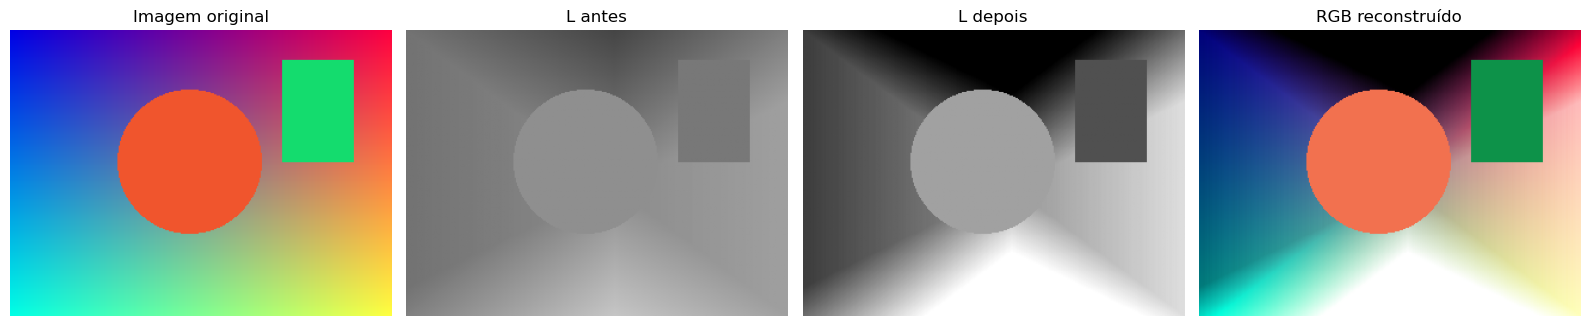

Intervalo L antes: [0.273, 0.773]
Intervalo L depois: [0.000, 1.000]


In [7]:
fig, eixos = plt.subplots(1, 4, figsize=(16, 4))
eixos[0].imshow(imagem_original)
eixos[0].set_title("Imagem original")
eixos[1].imshow(l_antes, cmap="gray", vmin=0, vmax=1)
eixos[1].set_title("L antes")
eixos[2].imshow(l_depois, cmap="gray", vmin=0, vmax=1)
eixos[2].set_title("L depois")
eixos[3].imshow(imagem_resultante)
eixos[3].set_title("RGB reconstruído")
for eixo in eixos:
    eixo.axis("off")
plt.tight_layout()
plt.show()

print(f"Intervalo L antes: [{l_antes.min():.3f}, {l_antes.max():.3f}]")
print(f"Intervalo L depois: [{l_depois.min():.3f}, {l_depois.max():.3f}]")

### Desafio extra — HSV: alteração do canal V
Para comparar os dois modelos com o mesmo procedimento, normalizamos V e aplicamos a mesma fórmula de contraste. Em HSL, L representa a média entre os extremos RGB; em HSV, V corresponde ao maior canal RGB. Por isso, a aparência dos resultados pode variar.

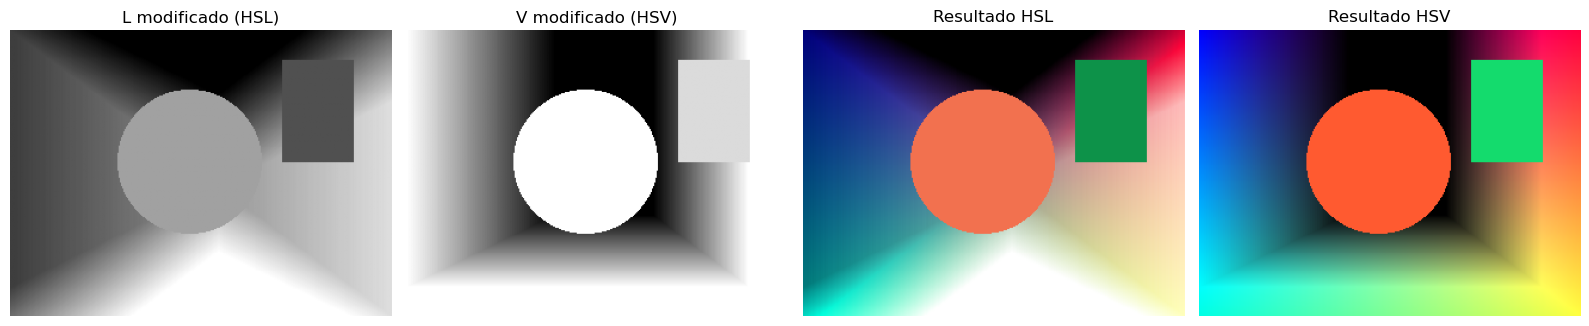

Diferença absoluta média entre saídas RGB (escala 0–1): 0.1752


In [8]:
hsv_original = rgb_to_hsv(rgb_original)
v_antes = hsv_original[..., 2].copy()
v_depois = aumentar_contraste(normalizar_canal(v_antes))
hsv_modificado = hsv_original.copy()
hsv_modificado[..., 2] = v_depois
resultado_hsv = hsv_to_rgb(hsv_modificado)
imagem_hsv = Image.fromarray(np.rint(resultado_hsv * 255).astype(np.uint8), "RGB")
imagem_hsv.save("questao2_contraste_hsv.png")

fig, eixos = plt.subplots(1, 4, figsize=(16, 4))
for eixo, img, titulo, cmap in zip(
    eixos,
    [l_depois, v_depois, imagem_resultante, imagem_hsv],
    ["L modificado (HSL)", "V modificado (HSV)", "Resultado HSL", "Resultado HSV"],
    ["gray", "gray", None, None],
):
    if cmap:
        eixo.imshow(img, cmap=cmap, vmin=0, vmax=1)
    else:
        eixo.imshow(img)
    eixo.set_title(titulo)
    eixo.axis("off")
plt.tight_layout()
plt.show()

mae = np.mean(np.abs(rgb_resultante - resultado_hsv))
print(f"Diferença absoluta média entre saídas RGB (escala 0–1): {mae:.4f}")

---
# Questão 3 — Imagem matricial de uma função discreta

**Situação-problema:** gerar imagens a partir de funções matemáticas amostradas em coordenadas inteiras.

**Itens solicitados:** (1) considerar $f(x,y)=(x-50)^2+(y-50)^2$; (2) gerar matriz de tamanho $100\times100$; (3) normalizar para o intervalo de 0 a 255; (4) converter a matriz em bitmap; (5) mostrar matriz numérica, imagem em cinza e gráfico 3D da função.

**Desafio extra:** produzir um mapa de calor RGB combinando os canais aditivos vermelho, verde e azul.

**Observação:** a matriz representa $f$ sem normalização; a imagem em cinza utiliza os valores normalizados. O mínimo da função ocorre em $(50,50)$.

In [9]:
largura = altura = 100
x = np.arange(largura)
y = np.arange(altura)
X, Y = np.meshgrid(x, y)
matriz = (X - 50)**2 + (Y - 50)**2

f_min, f_max = matriz.min(), matriz.max()
normalizada = (matriz - f_min) / (f_max - f_min)
matriz_uint8 = np.rint(normalizada * 255).astype(np.uint8)
imagem_funcao = Image.fromarray(matriz_uint8)
imagem_funcao.save("questao3_funcao_cinza.png")

assert matriz.shape == (100, 100)
assert matriz[50, 50] == 0
assert matriz_uint8.min() == 0 and matriz_uint8.max() == 255
print(f"Matriz: {matriz.shape} | f mínimo={f_min} | f máximo={f_max}")
print("Matriz numérica — canto superior esquerdo (5 × 5):")
print(matriz[:5, :5])

Matriz: (100, 100) | f mínimo=0 | f máximo=5000
Matriz numérica — canto superior esquerdo (5 × 5):
[[5000 4901 4804 4709 4616]
 [4901 4802 4705 4610 4517]
 [4804 4705 4608 4513 4420]
 [4709 4610 4513 4418 4325]
 [4616 4517 4420 4325 4232]]


### 3.1 — Matriz numérica completa
O quadro abaixo apresenta os **10.000 valores** de `matriz`. Role dentro da saída para consultar todas as linhas sem ocupar toda a tela.

In [10]:
# Versão integral da matriz, com rolagem vertical e horizontal no notebook.
import html
with np.printoptions(threshold=np.inf, linewidth=145):
    texto_matriz = np.array2string(matriz)
display(HTML(
    '<pre style="max-height:360px;overflow:auto;border:1px solid #aaa;'
    'padding:12px;font-size:11px;line-height:1.3">'
    + html.escape(texto_matriz) + '</pre>'
))

### 3.2 — Bitmap em cinza e gráfico tridimensional
A visualização 3D usa a **função original** (`matriz`), não os pixels de 0 a 255.

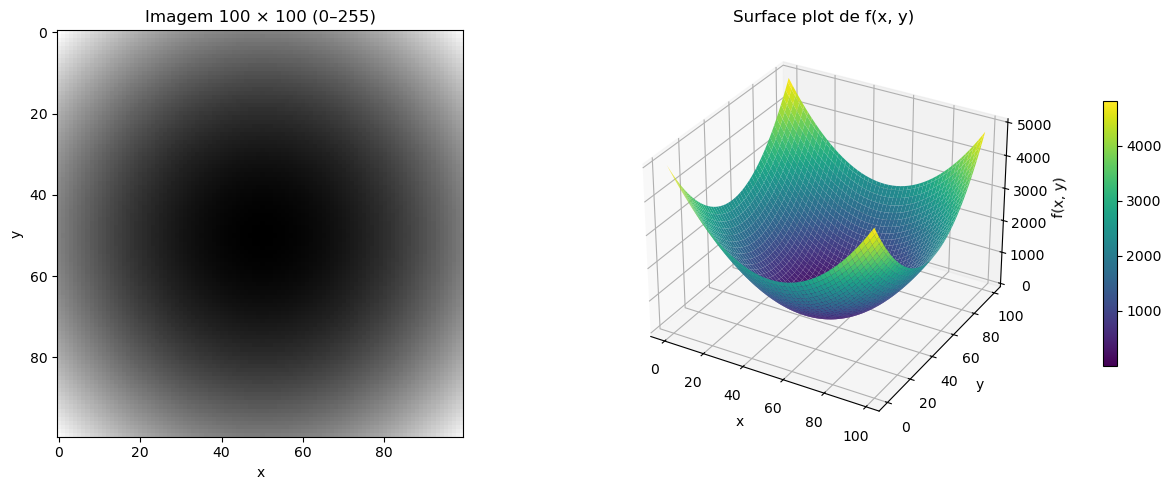

In [11]:
fig = plt.figure(figsize=(13, 5))
eixo_img = fig.add_subplot(1, 2, 1)
eixo_img.imshow(imagem_funcao, cmap="gray", vmin=0, vmax=255)
eixo_img.set_title("Imagem 100 × 100 (0–255)")
eixo_img.set_xlabel("x")
eixo_img.set_ylabel("y")

eixo_3d = fig.add_subplot(1, 2, 2, projection="3d")
superficie = eixo_3d.plot_surface(X, Y, matriz, cmap="viridis", linewidth=0)
eixo_3d.set_title("Surface plot de f(x, y)")
eixo_3d.set_xlabel("x")
eixo_3d.set_ylabel("y")
eixo_3d.set_zlabel("f(x, y)")
fig.colorbar(superficie, ax=eixo_3d, shrink=0.65, pad=0.12)
plt.tight_layout()
plt.show()

### Desafio extra — Mapa de calor RGB aditivo
Com $u$ sendo a função normalizada entre 0 e 1, construímos **R crescente**, **G máximo nos valores intermediários** e **B decrescente**. A combinação dos três canais forma um mapa colorido, sem alterar a matriz original.

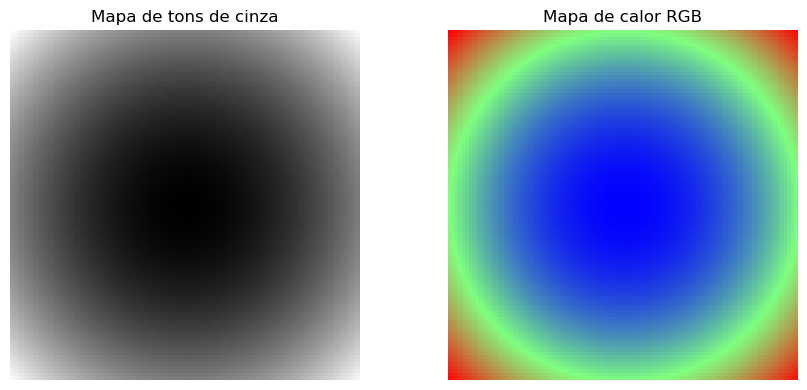

Imagem colorida salva: questao3_mapa_calor_rgb.png


In [12]:
u = normalizada
vermelho = np.clip(u, 0, 1)
verde = np.clip(1 - np.abs(2*u - 1), 0, 1)
azul = np.clip(1 - u, 0, 1)
mapa_rgb = np.rint(255*np.stack([vermelho, verde, azul], axis=-1)).astype(np.uint8)
imagem_calor = Image.fromarray(mapa_rgb)
imagem_calor.save("questao3_mapa_calor_rgb.png")

fig, eixos = plt.subplots(1, 2, figsize=(9, 4))
eixos[0].imshow(imagem_funcao, cmap="gray", vmin=0, vmax=255)
eixos[0].set_title("Mapa de tons de cinza")
eixos[1].imshow(imagem_calor)
eixos[1].set_title("Mapa de calor RGB")
for eixo in eixos:
    eixo.axis("off")
plt.tight_layout()
plt.show()
print("Imagem colorida salva: questao3_mapa_calor_rgb.png")

---
# Questão 3 — Continuação: desenvolver os cinco emojis

A **última página do PDF** também usa o título “QUESTÃO3” e apresenta cinco referências visuais, sem instruções adicionais. Para contemplá-la, a solução abaixo desenha cinco versões **aproximadas**, usando formas geométricas rasterizadas com Pillow: (1) olhos abertos e boca reta; (2) expressão neutra com olhos em traços; (3) olhos semicerrados e boca aberta; (4) olhos voltados para cima; e (5) olhos abertos e boca triste.

A implementação utiliza rosto circular amarelo/laranja com degradê, olhos, pupilas, sobrancelhas e diferentes bocas. Cada emoji é gerado em RGBA, e uma montagem final é salva em PNG.

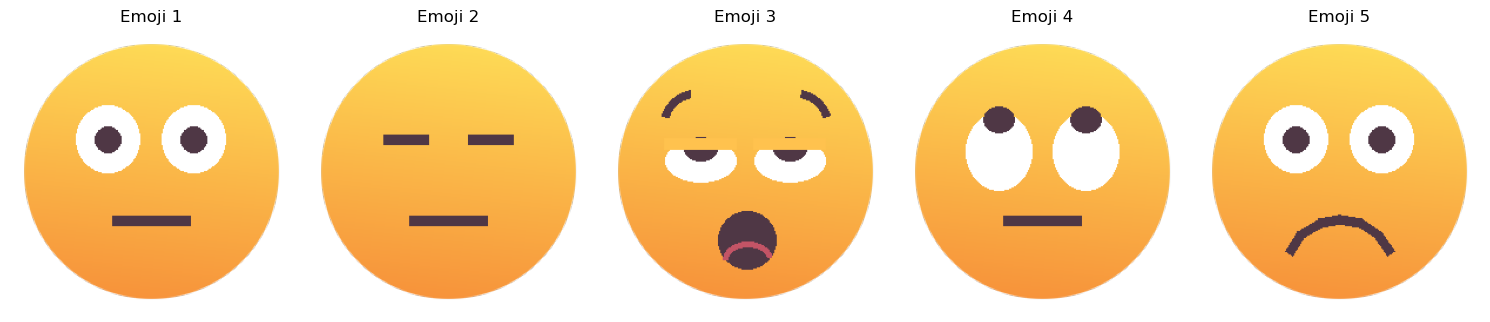

Cinco emojis gerados e salvos em questao3_emojis.png


In [13]:
def criar_emoji(tipo, tamanho=240):
    """Desenha uma aproximação geométrica de um dos cinco emojis do PDF."""
    s = tamanho / 240
    imagem = Image.new("RGBA", (tamanho, tamanho), (0, 0, 0, 0))

    # Rosto circular com degradê RGB e borda antisserrilhada por alfa.
    yy, xx = np.mgrid[0:tamanho, 0:tamanho]
    distancia = np.sqrt((xx - 120*s)**2 + (yy - 120*s)**2)
    mistura = np.clip((yy / (tamanho - 1)) * 0.85 + (1 - xx/(tamanho - 1))*0.10, 0, 1)
    cor_topo = np.array([255, 227, 89])
    cor_base = np.array([246, 135, 54])
    face = cor_topo[None, None, :] * (1 - mistura[..., None]) + cor_base[None, None, :] * mistura[..., None]
    alfa = np.clip((109*s - distancia) / max(1.2*s, 1e-8), 0, 1) * 255
    pixels = np.dstack([face.astype(np.uint8), alfa.astype(np.uint8)])
    imagem = Image.alpha_composite(imagem, Image.fromarray(pixels, "RGBA"))
    p = ImageDraw.Draw(imagem)

    def caixa(a, b, c, d):
        return tuple(round(v*s) for v in (a, b, c, d))

    escuro = (79, 55, 69, 255)
    branco = (255, 255, 255, 255)
    traco = max(3, round(9*s))

    if tipo in (1, 5):
        for cx in (83, 156):
            p.ellipse(caixa(cx-27, 64, cx+27, 121), fill=branco)
            p.ellipse(caixa(cx-11, 82, cx+11, 104), fill=escuro)
    elif tipo == 2:
        p.line([tuple(round(v*s) for v in ponto) for ponto in [(65,93),(103,93)]], fill=escuro, width=traco)
        p.line([tuple(round(v*s) for v in ponto) for ponto in [(137,93),(175,93)]], fill=escuro, width=traco)
    elif tipo == 3:
        for cx in (82, 158):
            p.ellipse(caixa(cx-30, 93, cx+30, 129), fill=branco)
            p.ellipse(caixa(cx-14, 91, cx+14, 111), fill=escuro)
            p.line([tuple(round(v*s) for v in ponto) for ponto in [(cx-31,96),(cx+30,96)]], fill=(255,194,78,255), width=round(10*s))
        p.arc(caixa(47, 51, 107, 117), start=200, end=262, fill=escuro, width=round(7*s))
        p.arc(caixa(134, 51, 194, 117), start=278, end=340, fill=escuro, width=round(7*s))
    elif tipo == 4:
        for cx in (83, 157):
            p.ellipse(caixa(cx-28, 70, cx+28, 136), fill=branco)
            p.ellipse(caixa(cx-13, 65, cx+13, 87), fill=escuro)

    if tipo in (1, 2, 4):
        p.line([tuple(round(v*s) for v in ponto) for ponto in [(87,162),(153,162)]], fill=escuro, width=traco)
    elif tipo == 3:
        p.ellipse(caixa(97,154,146,203), fill=escuro)
        p.arc(caixa(101,180,143,211), start=180, end=350, fill=(195,84,102,255), width=max(3,round(5*s)))
    elif tipo == 5:
        pontos = [(77,190),(87,174),(104,164),(120,161),(138,164),(153,174),(164,190)]
        p.line([tuple(round(v*s) for v in ponto) for ponto in pontos], fill=escuro, width=max(3,round(9*s)), joint="curve")
    return imagem


emojis = [criar_emoji(numero) for numero in range(1, 6)]
montagem = Image.new("RGBA", (5*240, 240), (255, 255, 255, 255))
for indice, emoji in enumerate(emojis):
    montagem.alpha_composite(emoji, (indice * 240, 0))
montagem.convert("RGB").save("questao3_emojis.png")

fig, eixos = plt.subplots(1, 5, figsize=(15, 3.5))
for indice, (eixo, emoji) in enumerate(zip(eixos, emojis), start=1):
    eixo.imshow(emoji)
    eixo.set_title(f"Emoji {indice}")
    eixo.axis("off")
plt.tight_layout()
plt.show()
print("Cinco emojis gerados e salvos em questao3_emojis.png")

---
## Arquivos gerados ao executar o notebook

- `questao1_bitmap_cinza.png` — composição vetorial rasterizada em cinza.
- `questao2_contraste_hsl.png` e `questao2_contraste_hsv.png` — filtros para comparar os modelos.
- `questao3_funcao_cinza.png` e `questao3_mapa_calor_rgb.png` — bitmap e mapa de calor da função.
- `questao3_emojis.png` — montagem com os cinco rostos.

O notebook já pode ser executado de cima para baixo no Google Colab. Para testar a **Questão 2 com uma fotografia sua**, altere `USAR_UPLOAD_COLAB` para `True` na célula de carregamento e execute novamente a partir dela.